In [92]:
import pandas as pd

from lifelines import KaplanMeierFitter, AalenJohansenFitter

import seaborn as sns
import matplotlib.pyplot as plt

# Get Data

In [94]:
df = pd.read_csv("../data/labeled_articles.csv")
df["published"] = pd.to_datetime(df["published"])

df.head()

# Get Survival Data

### **Key Labels**

**` lifecycle_label `**

- PROPOSAL
- CONSTRUCTION
- OPERATIONAL
- CANCELLATION
- UNRELATED

**` local_opposition`**

- `True` or `False`

## Transform Article Data

In [96]:
END_EVENTS = {"CONSTRUCTION", "OPERATIONAL"}


def to_reg_survival(group: pd.Grouper):
    """transform for kaplan-meier survival models"""

    # get related articles
    related = group[group["lifecycle_event"] != "UNRELATED"]
    if related.empty:
        return None

    first_mention_date = related["published"].min()
    end_events = group[group["lifecycle_event"].isin(END_EVENTS)]["published"]

    if end_events.empty:
        # if there is no clear end event, we use the last mention
        end_date = related["published"].max()
        event = 0
    else:
        # the latest mention of an end event.
        end_date = end_events.max()
        event = 1

    # calculate the duration from first mention
    duration_days = (end_date - first_mention_date).days
    opposition = int(len(group[group["local_opposition"] == True]) > 0)

    return pd.Series({
        "duration": duration_days,
        "event": event,
        "opposition": opposition,
    })


# apply to df
surv_reg = df.groupby("slug").apply(to_reg_survival).dropna().reset_index()
surv_reg.head()

C:\Users\Austin Muelrath\AppData\Local\Temp\ipykernel_24128\3186086287.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  surv_reg = df.groupby("slug").apply(to_reg_survival).dropna().reset_index()


,slug,duration,event,opposition,city,county,state,avg_year
0,(msp1)-west-twin-cities,0.0,0.0,0.0,Edina,Hennepin,Minnesota,2019.0
1,(ord2)-canal-street,691.0,1.0,1.0,Chicago,Cook,Illinois,2023.0
2,(ord4)-oak-brook,0.0,1.0,0.0,Oak Brook,DuPage,Illinois,2024.0
3,-san-francisco--ca,0.0,0.0,0.0,San Francisco,San Francisco,California,2020.0
4,0-rocky-creek-,102.0,0.0,0.0,Hampton,Henry,Georgia,2024.0


In [97]:
COMPLETION_EVENTS = {"CONSTRUCTION", "OPERATIONAL"}
CANCELLATION_EVENTS = {"CANCELLATION"}


def to_aj_survival(group: pd.DataFrame):
    """transform for aalen-johansen survival models"""

    related = group[group["lifecycle_event"] != "UNRELATED"]
    if related.empty:
        return None

    first_mention_date = related["published"].min()

    cancellation_dates = group[group["lifecycle_event"].isin(CANCELLATION_EVENTS)]["published"]
    completion_dates = group[group["lifecycle_event"].isin(COMPLETION_EVENTS)]["published"]

    if not cancellation_dates.empty:
        end_date = cancellation_dates.max()
        event = 2
    elif not completion_dates.empty:
        end_date = completion_dates.max()
        event = 1
    else:
        # no clear end event — use last mention, treated as censored
        end_date = related["published"].max()
        event = 0

    duration_days = (end_date - first_mention_date).days
    opposition = int(len(group[group["local_opposition"] == True]) > 0)

    return pd.Series({
        "duration": duration_days,
        "event": event,
        "opposition": opposition,
    })


# apply to df
surv_aj = df.groupby("slug").apply(to_aj_survival).dropna().reset_index()
surv_aj.head()

C:\Users\Austin Muelrath\AppData\Local\Temp\ipykernel_24128\2381347773.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  surv_aj = df.groupby("slug").apply(to_aj_survival).dropna().reset_index()


,slug,duration,event,opposition,city,county,state,avg_year
0,(msp1)-west-twin-cities,0.0,0.0,0.0,Edina,Hennepin,Minnesota,2019.0
1,(ord2)-canal-street,691.0,1.0,1.0,Chicago,Cook,Illinois,2023.0
2,(ord4)-oak-brook,0.0,1.0,0.0,Oak Brook,DuPage,Illinois,2024.0
3,-san-francisco--ca,0.0,0.0,0.0,San Francisco,San Francisco,California,2020.0
4,0-rocky-creek-,102.0,0.0,0.0,Hampton,Henry,Georgia,2024.0


# Survival Analysis

## Base KM

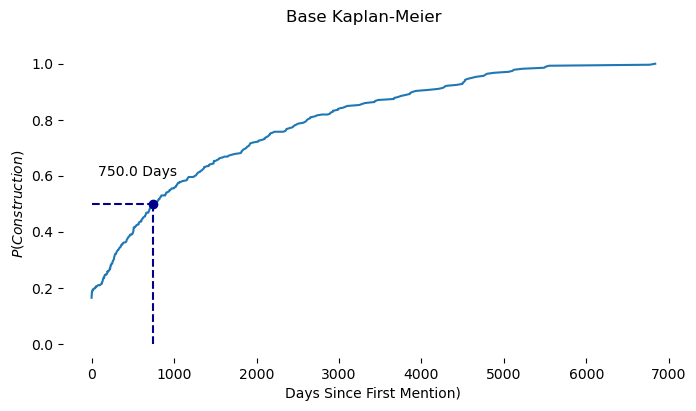

In [111]:
kmf_base = KaplanMeierFitter()
kmf_base.fit(durations=surv_reg["duration"], event_observed=surv_reg["event"])

density = kmf_base.cumulative_density_

base_km, ax = plt.subplots(figsize=(8, 4))

base_km.suptitle("Base Kaplan-Meier")

sns.lineplot(density, x="timeline", y="KM_estimate", ax=ax)

# median marker
ax.plot(kmf_base.median_survival_time_, 0.5, c="darkblue", marker="o")

# dotted lines to the median point
ax.vlines(
    x=kmf_base.median_survival_time_,
    ymin=0,
    ymax=0.5,
    linestyle="--",
    color="darkblue"
)
ax.hlines(
    y=0.5,
    xmin=0,
    xmax=kmf_base.median_survival_time_,
    linestyle="--",
    color="darkblue"
)

# median day annotation
ax.annotate(
    f"{kmf_base.median_survival_time_} Days",
    xy=(kmf_base.median_survival_time_ * 0.10, 0.6)
)

ax.set_ylabel("$P(Construction)$")
ax.set_xlabel("Days Since First Mention)")

ax.set_axisbelow(True)
ax.set_frame_on(False)

plt.show()

## Opposition-Segmented KM

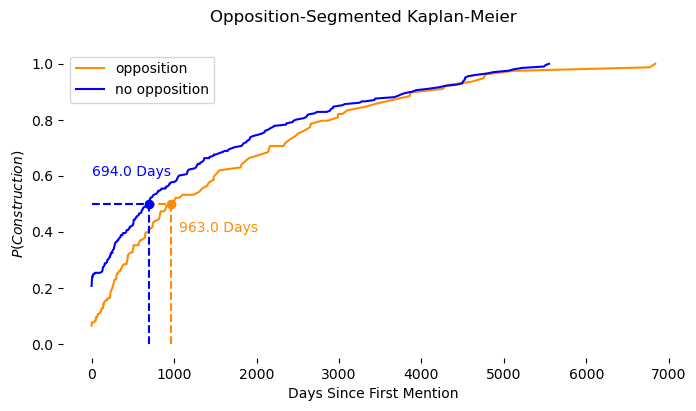

In [112]:
surv_reg_opp = surv_reg[surv_reg['opposition'] == 1]
surv_reg_no_opp = surv_reg[surv_reg['opposition'] == 0]

km_opp = KaplanMeierFitter()
km_opp.fit(durations=surv_reg_opp["duration"], event_observed=surv_reg_opp["event"])

km_no_opp = KaplanMeierFitter()
km_no_opp.fit(durations=surv_reg_no_opp["duration"], event_observed=surv_reg_no_opp["event"])

segmented_km, ax = plt.subplots(figsize=(8, 4))

segmented_km.suptitle("Opposition-Segmented Kaplan-Meier")

# plot cumulative density for each group
sns.lineplot(km_opp.cumulative_density_, x="timeline", y="KM_estimate",
             ax=ax, color="darkorange", label="opposition")
sns.lineplot(km_no_opp.cumulative_density_, x="timeline", y="KM_estimate",
             ax=ax, color="blue", label="no opposition")

# median markers and dotted lines for opposition
ax.plot(km_opp.median_survival_time_, 0.5, c="darkorange", marker="o")
ax.vlines(
    x=km_opp.median_survival_time_,
    ymin=0,
    ymax=0.5,
    linestyle="--",
    color="darkorange"
)
ax.hlines(
    y=0.5,
    xmin=0,
    xmax=km_opp.median_survival_time_,
    linestyle="--",
    color="darkorange"
)

ax.annotate(
    f"{km_opp.median_survival_time_} Days",
    xy=(km_opp.median_survival_time_ * 1.1, 0.4),
    c="darkorange"
)

# median markers and dotted lines for no opposition
ax.plot(km_no_opp.median_survival_time_, 0.5, c="blue", marker="o")
ax.vlines(
    x=km_no_opp.median_survival_time_,
    ymin=0,
    ymax=0.5,
    linestyle="--",
    color="blue"
)
ax.hlines(
    y=0.5,
    xmin=0,
    xmax=km_no_opp.median_survival_time_,
    linestyle="--",
    color="blue"
)

ax.annotate(
    f"{km_no_opp.median_survival_time_} Days",
    xy=(km_no_opp.median_survival_time_ * 0.01, 0.6),
    c="blue"
)

ax.set_ylabel("$P(Construction)$")
ax.set_xlabel("Days Since First Mention")

ax.set_axisbelow(True)
ax.set_frame_on(False)

plt.legend()
plt.show()

## Base AJ

C:\miniforge3\envs\data-centers\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


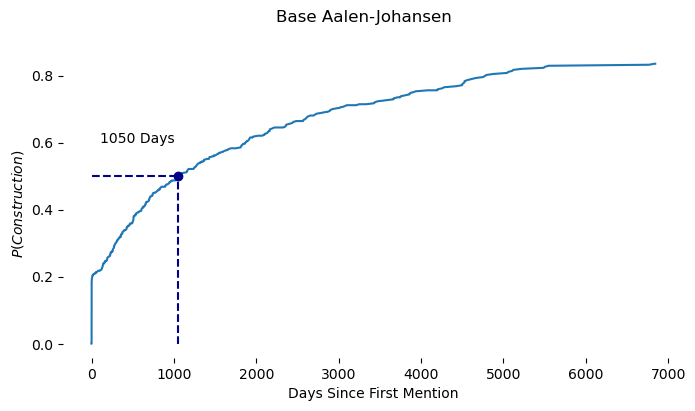

In [113]:
aj = AalenJohansenFitter()
aj.fit(durations=surv_aj["duration"], event_observed=surv_aj["event"], event_of_interest=1)

base_aj, ax = plt.subplots(figsize=(8, 4))
base_aj.suptitle("Base Aalen-Johansen")

sns.lineplot(aj.cumulative_density_, x="event_at", y="CIF_1", ax=ax)

# median marker
median_time = aj.cumulative_density_[aj.cumulative_density_["CIF_1"] >= 0.5].index[0]

ax.plot(median_time, 0.5, c="darkblue", marker="o")

ax.vlines(
    x=median_time,
    ymin=0,
    ymax=0.5,
    linestyle="--",
    color="darkblue"
)
ax.hlines(
    y=0.5,
    xmin=0,
    xmax=median_time,
    linestyle="--",
    color="darkblue"
)

ax.annotate(
    f"{median_time:.0f} Days",
    xy=(median_time * 0.10, 0.6)
)

ax.set_ylabel("$P(Construction)$")
ax.set_xlabel("Days Since First Mention")

ax.set_axisbelow(True)
ax.set_frame_on(False)

plt.show()

## Opposition-Segmented AJ

C:\miniforge3\envs\data-centers\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
C:\miniforge3\envs\data-centers\Lib\site-packages\lifelines\fitters\aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


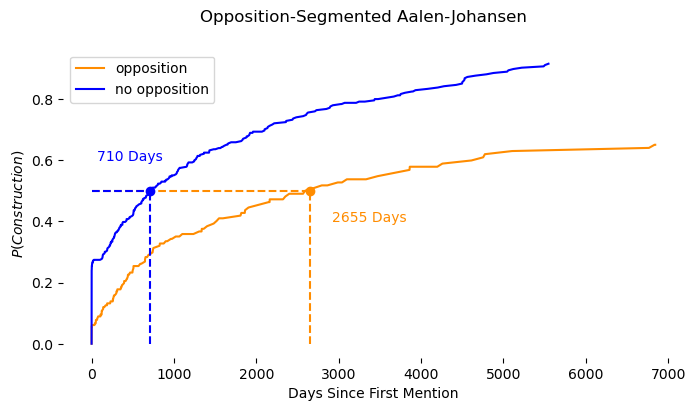

In [114]:
# split data
surv_aj_opp = surv_aj[surv_aj['opposition'] == 1]
surv_aj_no_opp = surv_aj[surv_aj['opposition'] == 0]

# fit models for opp and no opp
aj_opp = AalenJohansenFitter()
aj_opp.fit(durations=surv_aj_opp["duration"], event_observed=surv_aj_opp["event"], event_of_interest=1)

aj_no_opp = AalenJohansenFitter()
aj_no_opp.fit(durations=surv_aj_no_opp["duration"], event_observed=surv_aj_no_opp["event"], event_of_interest=1)

# plot
segmented_aj, ax = plt.subplots(figsize=(8, 4))
segmented_aj.suptitle("Opposition-Segmented Aalen-Johansen")

sns.lineplot(aj_opp.cumulative_density_, x="event_at", y="CIF_1", ax=ax, color="darkorange", label="opposition")
sns.lineplot(aj_no_opp.cumulative_density_, x="event_at", y="CIF_1", ax=ax, color="blue", label="no opposition")

# median markers for opposition
cif_opp_above = aj_opp.cumulative_density_[aj_opp.cumulative_density_["CIF_1"] >= 0.5]
if not cif_opp_above.empty:
    median_opp = cif_opp_above.index[0]
    ax.plot(median_opp, 0.5, c="darkorange", marker="o")
    ax.vlines(x=median_opp, ymin=0, ymax=0.5, linestyle="--", color="darkorange")
    ax.hlines(y=0.5, xmin=0, xmax=median_opp, linestyle="--", color="darkorange")

    # median annotation for opp
    ax.annotate(
        f"{median_opp:.0f} Days",
        xy=(median_opp * 1.1, 0.4),
        c="darkorange"
    )

# median markers for no opposition
cif_no_opp_above = aj_no_opp.cumulative_density_[aj_no_opp.cumulative_density_["CIF_1"] >= 0.5]
if not cif_no_opp_above.empty:
    median_no_opp = cif_no_opp_above.index[0]
    ax.plot(median_no_opp, 0.5, c="blue", marker="o")
    ax.vlines(x=median_no_opp, ymin=0, ymax=0.5, linestyle="--", color="blue")
    ax.hlines(y=0.5, xmin=0, xmax=median_no_opp, linestyle="--", color="blue")

    # median annotation for no opp
    ax.annotate(
        f"{median_no_opp:.0f} Days",
        xy=(median_no_opp * 0.1, 0.6),
        c="blue"
    )

ax.set_ylabel("$P(Construction)$")
ax.set_xlabel("Days Since First Mention")

ax.set_axisbelow(True)
ax.set_frame_on(False)

plt.legend()
plt.show()

## Final CI Plots

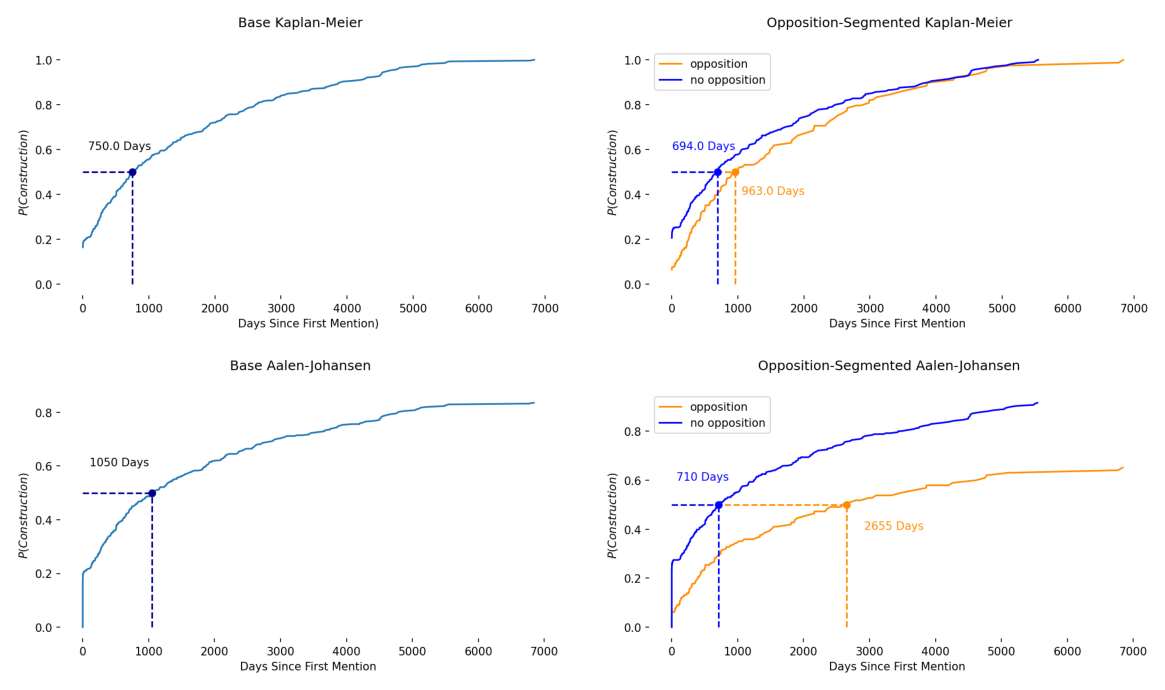

In [115]:
import io
from PIL import Image


def fig_to_img(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=150, bbox_inches="tight")
    buf.seek(0)
    return Image.open(buf)


imgs = [fig_to_img(base_km), fig_to_img(segmented_km),
        fig_to_img(base_aj), fig_to_img(segmented_aj)]

fig, axes = plt.subplots(figsize=(12, 7), nrows=2, ncols=2)
for ax, img in zip(axes.flatten(), imgs):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()